In [1]:
from collections import defaultdict
from tqdm import tqdm
from functools import reduce
import ast
import numpy as np
from typing import List, Dict, Tuple
import matplotlib.pyplot as plt
import json
import hashlib
import pandas as pd

BASE_DATASET_PATH = "../../data/qa_datasets/v2/rubq_dev"

LOAD_DATASET_PATH = f"{BASE_DATASET_PATH}/original"
SAVE_CONTEXTS_PATH = f"{BASE_DATASET_PATH}/relevant_contexts.csv"
SAVE_TMP_CONTEXTS_PATH = f"{BASE_DATASET_PATH}/tmp_rubqdev_cntx.csv"
SAVE_QA_PATH = f"{BASE_DATASET_PATH}/qa_pairs.csv"
SAVE_STATS_PATH = f"{BASE_DATASET_PATH}/stats.json"

CNTX_MAX_LEN = 1024
CNTX_MIN_LEN = 64
MAX_QA_PAIRS = 4000
NOIZE_CONTEXTS_AMOUNT = 1500

In [2]:
with open(f"{LOAD_DATASET_PATH}/RuBQ_2.0_test.json", 'r') as fd:
    qa_pairs = json.load(fd)

In [3]:
with open(f"{LOAD_DATASET_PATH}/RuBQ_2.0_paragraphs.json", 'r') as fd:
    contexts = json.load(fd)

In [4]:
filtered_contexts = [(item['uid'], item['text']) for item in contexts if (len(item['text']) > CNTX_MIN_LEN) and (len(item['text']) < CNTX_MAX_LEN)]
print(len(filtered_contexts))
uniques_context_ids = set([item[0] for item in filtered_contexts])
print(len(uniques_context_ids))

49139
49139


In [5]:
formated_qa = [[item['uid'], item['question_text'], item['answer_text'], item['paragraphs_uids']['with_answer'], item['tags']] for item in qa_pairs]
print(len(formated_qa))
filtered_qa = list(filter(lambda item: len(item[3]), formated_qa))
print(len(filtered_qa))
filtered_qa = list(filter(lambda item: 'no-answer' not in item[4], filtered_qa))
print(len(filtered_qa))
filtered_qa = [item for item in filtered_qa if len(set(item[3]).intersection(uniques_context_ids)) == len(item[3]) ]
print(len(filtered_qa))
qa_df = pd.DataFrame(filtered_qa[:MAX_QA_PAIRS], columns=['qa_uid', 'question', 'answer', 'context_ids', 'tags'])

uniques_relevant_context_ids = set(reduce(lambda acc, v: acc + v, qa_df['context_ids'].tolist(), []))
print(len(uniques_relevant_context_ids))

2330
1694
1548
1350
2003


In [6]:
qa_df

,qa_uid,question,answer,context_ids,tags
0,0,Что может вызвать цунами?,Землетрясение,[35622],[1-hop]
1,1,Кто написал роман «Хижина дяди Тома»?,Г. Бичер-Стоу,[35652],[1-hop]
2,2,Кто автор пьесы «Ромео и Джульетта»?,Шекспир,"[35676, 35677]",[1-hop]
3,5,На каком инструменте играл Джимми Хендрикс?,Гитара,"[35728, 35727]",[1-hop]
4,6,Какой стране принадлежит остров Таити?,Франции,"[35756, 35757, 35758, 35759]",[1-hop]
...,...,...,...,...,...
1345,7192,В каком году Ливонский орден прекратил существ...,в 1561 году,"[23066, 23067]",[multi-constraint]
1346,7194,В каком году открыт памятник пельменю в Миассе?,5 января 2018 года,[31756],[multi-constraint]
1347,7195,Какая площадь Азовского моря?,39 000 км2,[31524],[1-hop]
1348,7197,Какая площадь Казахстана?,2 725 000 км²,"[2266, 2283]",[1-hop]


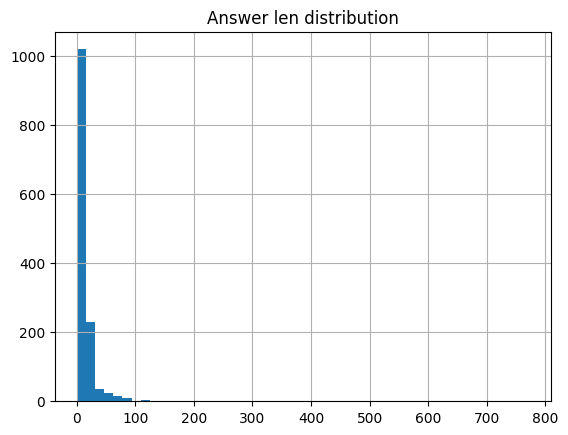

In [7]:
answer_lens = list(map(lambda cntx: len(cntx), qa_df['answer']))
plt.hist(answer_lens, bins=50)
plt.title("Answer len distribution")
plt.grid()
plt.show()

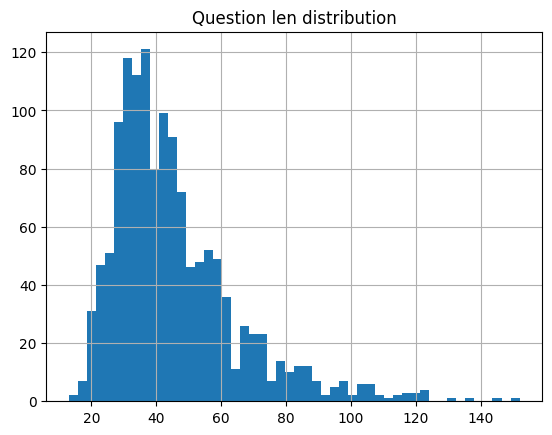

In [8]:
question_lens = list(map(lambda cntx: len(cntx), qa_df['question']))
plt.hist(question_lens, bins=50)
plt.title("Question len distribution")
plt.grid()
plt.show()

In [9]:
filtered_contexts = [(item['uid'], item['text']) for item in contexts if item['uid'] in uniques_relevant_context_ids]
print(len(filtered_contexts))

2003


In [10]:
unique_notrelevant_context_ids = uniques_context_ids.difference(uniques_relevant_context_ids)
print(len(unique_notrelevant_context_ids))
noize_contexts = [(item['uid'], item['text']) for item in contexts if item['uid'] in unique_notrelevant_context_ids][:NOIZE_CONTEXTS_AMOUNT]
print(len(noize_contexts))

47136
1500


In [11]:
cntx_df = pd.DataFrame(filtered_contexts + noize_contexts, columns=['cntx_uid', 'context'])

In [12]:
cntx_df

,cntx_uid,context
0,33,2-е место — 2006/07Восточная футбольная лига с...
1,57,"Белору́ссия (белор. Беларусь, [bʲɛlaˈrusʲ] сл..."
2,62,"Белоруссия делится на 6 областей, которые, в с..."
3,235,Территория России в её заявленных границах сос...
4,236,"Росси́я, другое официальное название — Росси́й..."
...,...,...
3498,1829,"Наман (индон. Namang) — район в Индонезии, в п..."
3499,1830,"Основные притоки Лены: Большой Патом, Чая, Вит..."
3500,1831,Протекает по территории Иркутской области и Як...
3501,1832,От Олёкмы до Алдана Лена не имеет ни одного зн...


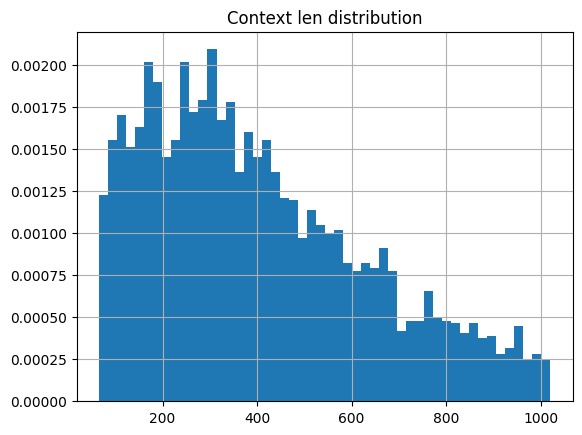

In [13]:
cntx_lens = list(map(lambda cntx: len(cntx), cntx_df['context']))
plt.hist(cntx_lens, bins=50, density=True)
plt.title("Context len distribution")
plt.grid()
plt.show()

In [14]:
qa_df.to_csv(SAVE_QA_PATH, index=False)
cntx_df.to_csv(SAVE_CONTEXTS_PATH, index=False)

#### Сохраняем статистику по полученным csv-файлам с контекстами и соответствующими qa-парами

In [15]:
qa_df = pd.read_csv(SAVE_QA_PATH)
cntx_df = pd.read_csv(SAVE_CONTEXTS_PATH)

In [16]:
def compute_stats(numbers: List[int]) -> Dict[str, float]:
    return {'median': round(np.median(numbers),5),
            'mean': round(np.mean(numbers),5),
            'std': round(np.std(numbers),5),
            'min': round(min(numbers),5),
            'max': round(max(numbers),5)}

In [17]:
filtered_ds_statistics = {
    'contexts_amount': cntx_df.shape[0],
    'contexts_len': compute_stats(list(map(lambda v: len(v), cntx_df['context'].tolist()))),
    'qa_pairs_amount': qa_df.shape[0],
    'answers_len':  compute_stats(list(map(lambda v: len(v), qa_df['answer'].tolist()))),
    'questions_len': compute_stats(list(map(lambda v: len(v), qa_df['question'].tolist())))
}

In [18]:
with open(SAVE_STATS_PATH, 'w', encoding='utf-8') as fd:
    json.dump(filtered_ds_statistics, fd, indent=1, ensure_ascii=False)